In [30]:
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10,5)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [15]:
df=pd.read_csv(r"R:\sipps_ss\api_datas\ip;l_\super_final.csv")
df

,POS,player_name,team,RUNS,MAT,INNS,NO,HS,AVG,BF,SR,100,50,4S,6S,season,status
0,1,Shaun Marsh,PBKS,616,11,11,2,115,68.44,441,139.68,1,5,59,26,2008,out
1,2,Gautam Gambhir,DC,534,14,14,1,86,41.07,379,140.89,0,5,68,8,2008,out
2,3,Sanath Jayasuriya,MI,518,14,14,2,114,43.16,309,167.63,1,2,58,31,2008,Not_out
3,4,Shane Watson,RR,472,15,15,5,76,47.2,311,151.76,0,4,47,19,2008,Not_out
4,5,Graeme Smith,RR,441,11,11,2,91,49.0,362,121.82,0,3,54,8,2008,out
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2604,97,Kumar Kartikeya Singh,RR,1,1,1,0,1,1.00,1,100.00,0,0,0,0,2025,out
2605,98,Sai Kishore,GT,1,2,1,0,1,1.00,1,100.00,0,0,0,0,2025,out
2606,99,Mohd Arshad Khan,GT,1,1,1,1,1,-,1,100.00,0,0,0,0,2025,Not_out
2607,100,Mohit Sharma,DC,1,2,1,1,1,-,2,50.00,0,0,0,0,2025,Not_out


In [18]:
df['AVG']=pd.to_numeric(df['AVG'],errors="coerce")


In [19]:
df.dropna(inplace=True)

# 3. Overall Dataset Understanding

#### Top Run Scorers (All Seasons)

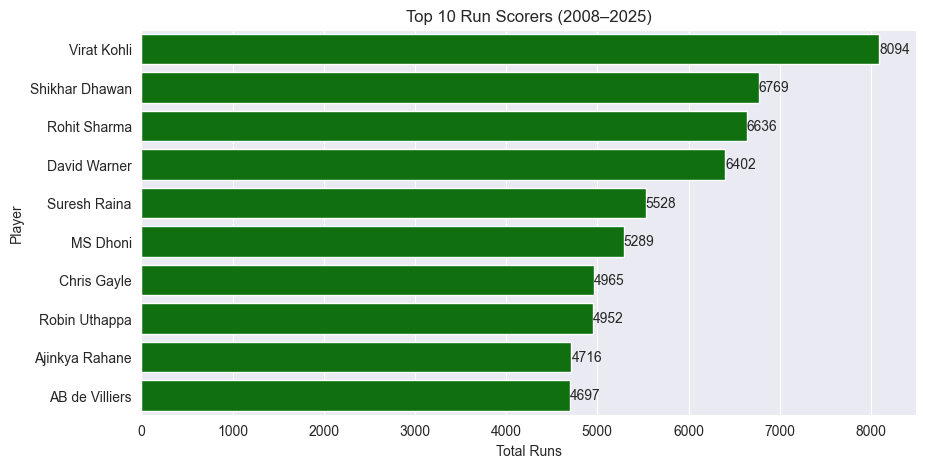

In [31]:
top_runs = df.groupby("player_name")["RUNS"].sum().sort_values(ascending=False).head(10)

ax=sns.barplot(x=top_runs.values, y=top_runs.index,color='green')
for label in ax.containers:
    plt.bar_label(label)
    
plt.title("Top 10 Run Scorers (2008–2025)")
plt.xlabel("Total Runs")
plt.ylabel("Player")
plt.show()

### 1. Top 10 Run Scorers (2008–2025)

🔍 Conclusion:
- Virat Kohli dominates the IPL run chart with the highest aggregate runs (~8000+), showing unmatched longevity and consistency.
- The top 5 players (Kohli, Dhawan, Rohit, Warner, Raina) form the core elite batting group of IPL history.
- Most top players are top-order batters, proving that maximum run accumulation happens in early batting positions.
The gap between Rank 1 and Rank 10 is significant, showing clear performance hierarchy in IPL batting.

 Key Insight:

- IPL batting performance is highly skewed — a small group of elite players dominate total career runs.

## Runs Distribution (All Players)

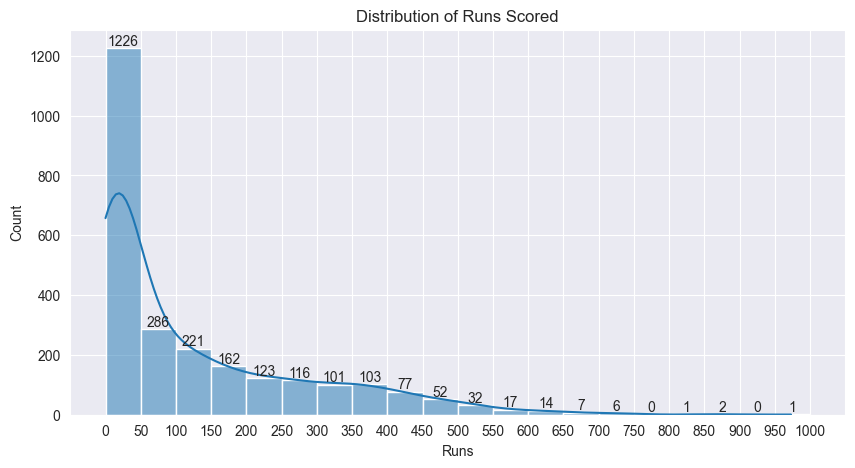

In [97]:
ax=sns.histplot(df["RUNS"], bins=[i for i in range(0,1050,50)], kde=True)
for label in ax.containers:
    plt.bar_label(label)
plt.xticks([i for i in range(0,1050,50)])
plt.title("Distribution of Runs Scored")
plt.xlabel("Runs")
plt.show()

## 2. Distribution of Runs Scored
🔍 Conclusion:
- The distribution is strongly right-skewed.
- Majority of players score in the range of 0–200 runs per season, indicating a large pool of low-impact players.
Very few players cross 500+ runs, making them rare elite performers.
- The long tail shows existence of occasional high-impact seasons (700–900 runs).

 Key Insight:

- IPL is a “star-driven league” — a small number of players contribute most of the runs.

## 4. Batting Average Analysis

#### Average Distribution

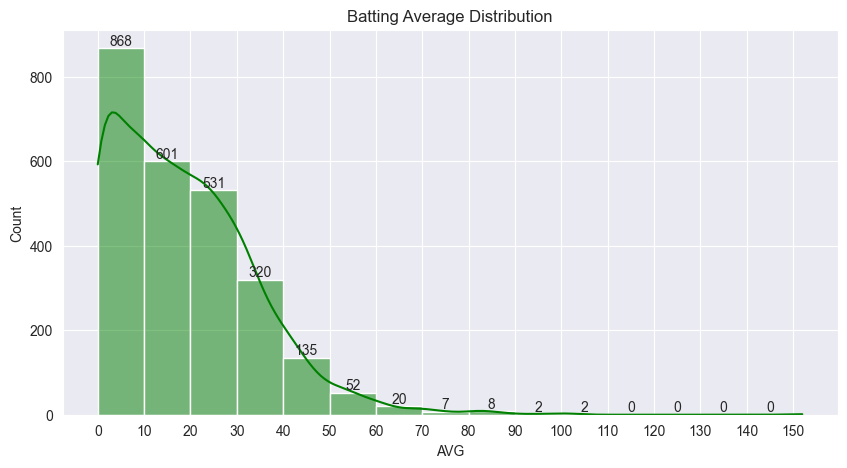

In [38]:
ax=sns.histplot(df["AVG"], bins=[ i for i in range(0,160,10)], kde=True, color="green")
for label in ax.containers:
    plt.bar_label(label)
    
plt.xticks([ i for i in range(0,160,10)])
plt.title("Batting Average Distribution")
plt.show()

## 3. Batting Average Distribution
🔍 Conclusion:
- Most players have an average between 10 and 35, showing moderate-to-low consistency across the league.
Very few players cross 50+ average, indicating elite consistency is rare in T20 cricket.
- The curve is right-skewed, meaning a few exceptional batters significantly raise the performance ceiling.
Outliers (70–150 AVG) often represent short but highly successful innings samples.

Key Insight:

- High batting average is rare in T20 — consistency is harder due to match format pressure.

## Top Averages (Min innings filter for fairness)

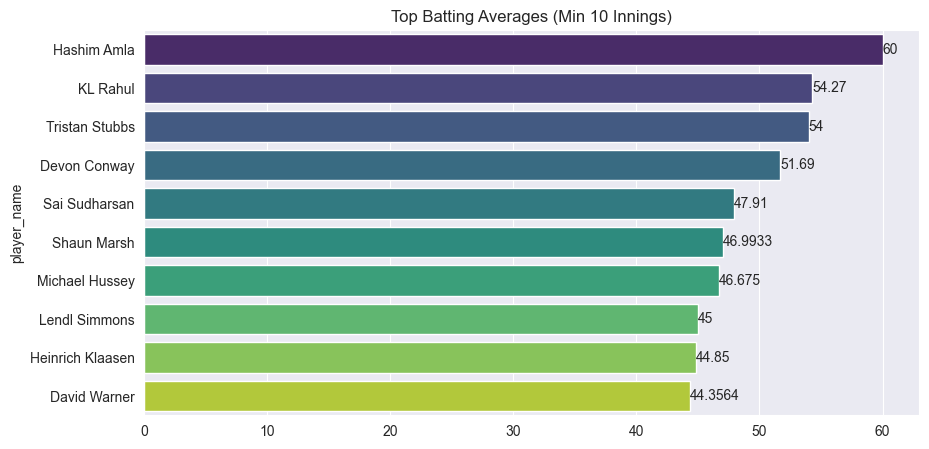

In [42]:
avg_players = df[df["INNS"] >= 10]
top_avg = avg_players.groupby("player_name")["AVG"].mean().sort_values(ascending=False).head(10)

ax=sns.barplot(x=top_avg.values, y=top_avg.index, palette="viridis")
for label in ax.containers:
    plt.bar_label(label)
    
plt.title("Top Batting Averages (Min 10 Innings)")
plt.show()

### Conclusion:
- Players like Hashim Amla, KL Rahul, Devon Conway dominate due to high consistency and controlled aggression.
The filter (min innings) ensures true performance quality instead of small-sample bias.
- Many top average players are technically strong anchors, not aggressive hitters.
- KL Rahul and similar players balance stability + scoring ability, making them high-value assets.

 Key Insight:

- High average players are not necessarily high strike rate players — they are “anchors”

## 5. Strike Rate Analysis (Modern T20 Impact)

### SR Distribution

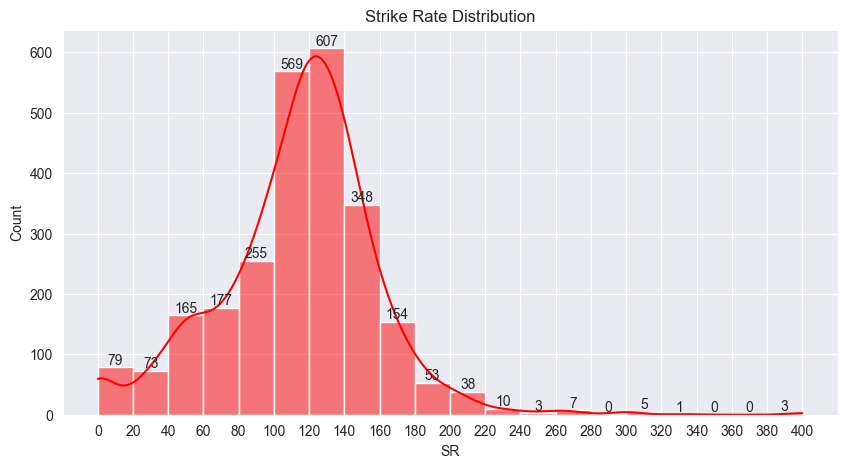

In [46]:
ax=sns.histplot(df["SR"], bins=[i for i in range(0,420,20)], kde=True, color="red")
for label in ax.containers:
    plt.bar_label(label)
    
plt.xticks([i for i in range(0,420,20)])
plt.title("Strike Rate Distribution")
plt.show()

### 5. Strike Rate Distribution
🔍 Conclusion:
- Most players fall between 100–140 strike rate, which is the “normal IPL scoring zone”.
- A clear peak around 120–130 SR shows the modern batting standard.
- Very few players exceed 180+ SR, marking elite power hitters.
The distribution shows a long right tail → explosive hitters are rare but game-changing.

 Key Insight:

- IPL batting is shifting toward higher strike rates, but elite explosiveness is still uncommon.

## Top Strike Rate Players (with condition)

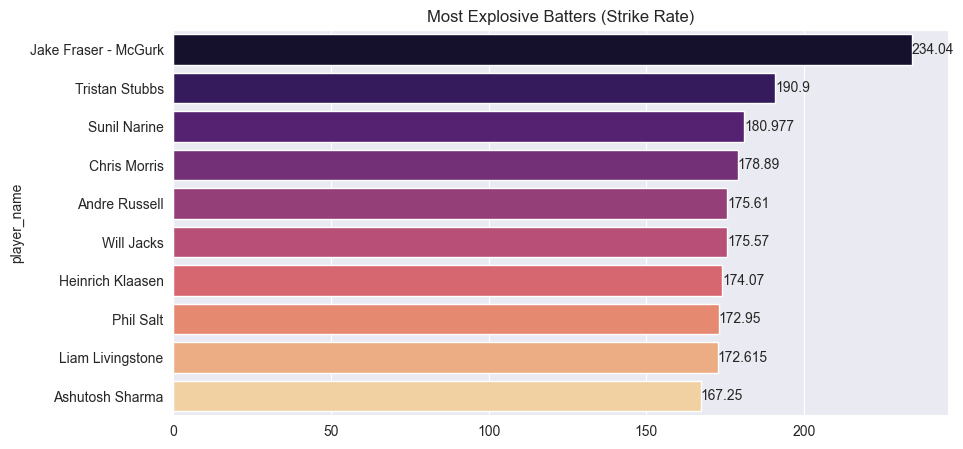

In [48]:
sr_players = df[df["BF"] > 100]

top_sr = sr_players.groupby("player_name")["SR"].mean().sort_values(ascending=False).head(10)

ax=sns.barplot(x=top_sr.values, y=top_sr.index, palette="magma")
for label in ax.containers:
    plt.bar_label(label)
    
plt.title("Most Explosive Batters (Strike Rate)")
plt.show()

##  Most Explosive Batters (Strike Rate)
Conclusion

- The chart highlights the batters with the highest strike rates in IPL history, emphasizing players who score at exceptional speed rather than accumulating large totals.

Key Insights
- Jake Fraser-McGurk leads with an extraordinary strike rate of 234.04, the highest among all players shown, indicating unmatched explosiveness.
- Tristan Stubbs (190.9) and Sunil Narine (180.98) follow, demonstrating the rise of ultra-aggressive modern batting.
- Traditional power hitters such as Andre Russell (175.61) and Heinrich Klaasen (174.07) remain among the most destructive players.
- The dominance of recent players suggests that T20 batting has evolved significantly, with teams prioritizing high strike rates over conventional accumulation.

# 6. Boundary Analysis (4s & 6s Impact)

## Most 6 Hitters

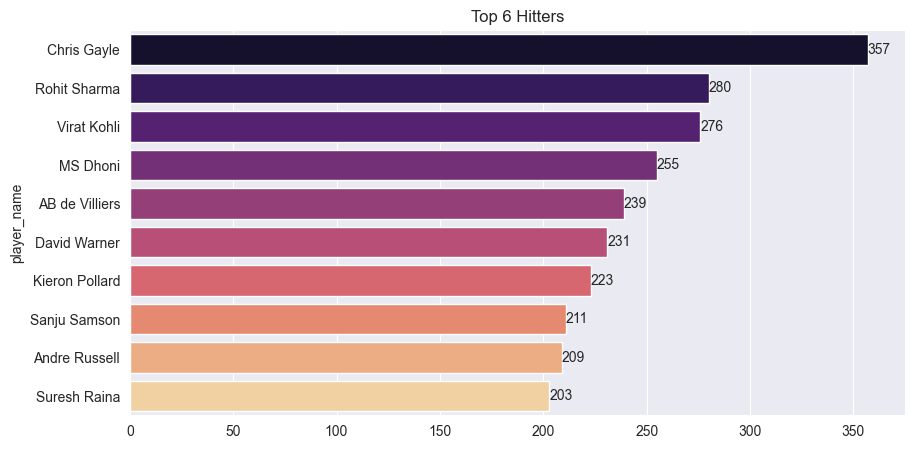

In [51]:
top_six = df.groupby("player_name")["6S"].sum().sort_values(ascending=False).head(10)

ax=sns.barplot(x=top_six.values, y=top_six.index,palette="magma")
for label in ax.containers:
    plt.bar_label(label)
    
plt.title("Top 6 Hitters")
plt.show()

## Conclusion

The chart identifies the players who have hit the most sixes in IPL history, reflecting long-term dominance and consistent power-hitting.

Key Insights
- Chris Gayle is far ahead with 357 sixes, solidifying his reputation as the greatest six-hitter in IPL history.
- Rohit Sharma (280) and Virat Kohli (276) combine longevity with aggressive stroke play.
- MS Dhoni (255) and AB de Villiers (239) showcase their ability to finish games with power.
- Players like Andre Russell have high strike rates but fewer total sixes due to shorter careers or fewer innings.

## 4s vs 6s Relationship

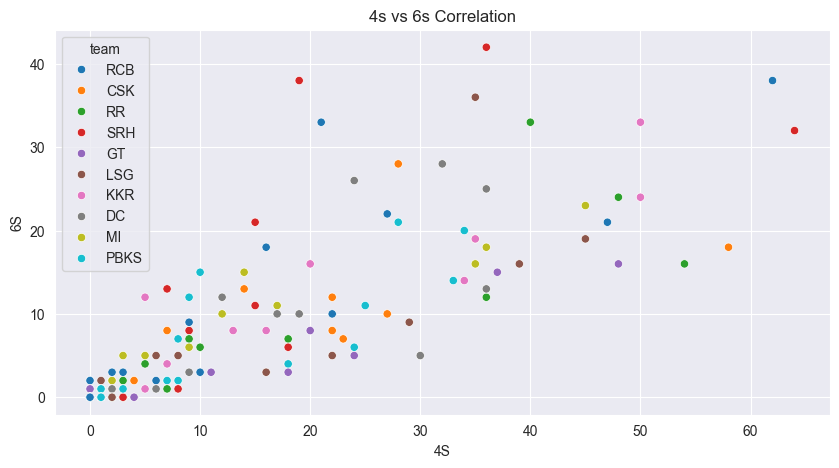

In [57]:
df_2007=df[df['season']==2024]
sns.scatterplot(data=df_2007, x="4S", y="6S", hue="team", alpha=1,color="red")
plt.title("4s vs 6s Correlation")
plt.show()

# Conclusion

There is a strong positive relationship between the number of fours and sixes scored by teams, indicating that aggressive batting leads to success in both boundary types.

Key Insights
- Teams that hit more fours generally also hit more sixes.
- SRH and RCB display some of the highest combined boundary counts, reflecting highly attacking batting strategies.
- Lower-left points represent conservative or underperforming batting innings.
- The spread suggests that teams vary in style—some rely on frequent fours, while others focus more on six-hitting.

## 7. Season-wise Performance Trend

### Total Runs per Season

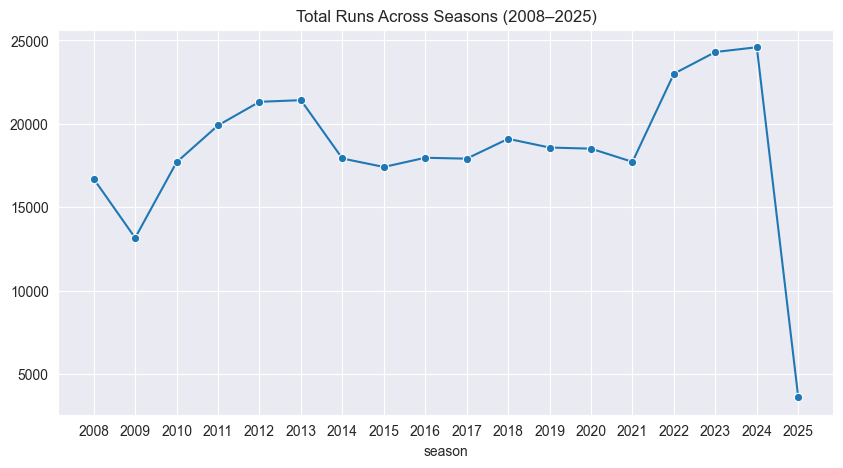

In [61]:
season_runs = df.groupby("season")["RUNS"].sum()

sns.lineplot(x=season_runs.index, y=season_runs.values, marker="o")
plt.xticks(df['season'].unique())
plt.title("Total Runs Across Seasons (2008–2025)")
plt.show()

## Conclusion

IPL scoring has increased significantly over time, with the highest run totals recorded in recent seasons.

Key Insights
- Total runs rose steadily after the early years, with notable growth from 2010 to 2013.
- A temporary plateau occurred between 2014 and 2021.
- A dramatic surge began in 2022, with 2024 recording the highest total runs (~24,700).
- The sharp drop in 2025 is due to an incomplete season rather than a true decline in scoring.
- The trend confirms that pitches, batting depth, and aggressive tactics have made the IPL increasingly high-scoring.

In [60]:
df['season'].unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020, 2021, 2022, 2023, 2024, 2025])

## Avg Strike Rate per Season

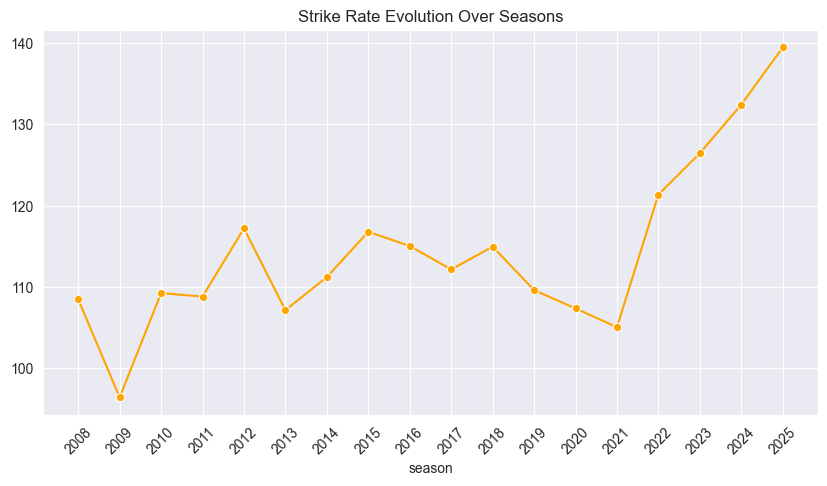

In [65]:
season_sr = df.groupby("season")["SR"].mean()

sns.lineplot(x=season_sr.index, y=season_sr.values, marker="o", color="orange")
plt.xticks(df['season'].unique(),rotation=45)
plt.title("Strike Rate Evolution Over Seasons")
plt.show()

## 5. Strike Rate Evolution Over Seasons
Conclusion

- Average strike rates have improved steadily, especially in the last few years, highlighting the transformation of batting approaches.

Key Insights
- Early seasons (2008–2021) mostly ranged between 105 and 117.
- From 2022 onward, strike rates increased sharply.
2025 reaches approximately 139.5, the highest in IPL history.
- The increase aligns with the emergence of fearless top-order batting and the influence of modern T20 analytics.

## 8. Player Consistency Analysis

## Runs vs Matches

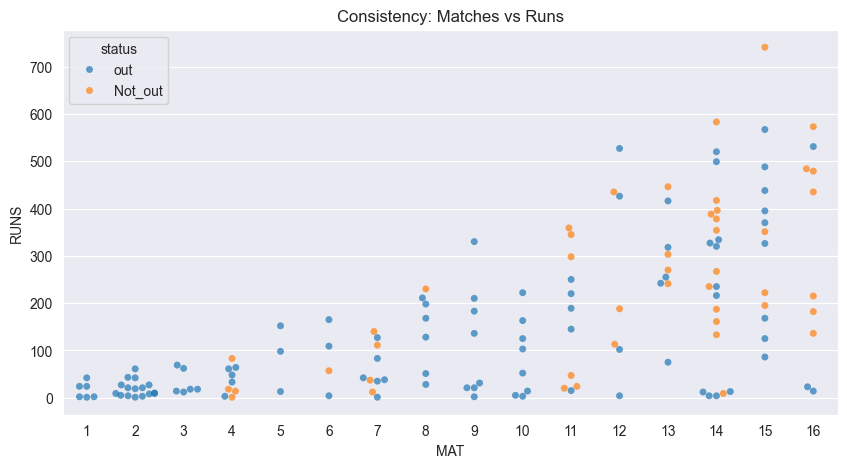

In [68]:
sns.swarmplot(data=df_2007, x="MAT", y="RUNS", hue="status", alpha=0.7)
plt.title("Consistency: Matches vs Runs")
plt.show()

## 9. Performance Clustering Insight (Elite vs Average)

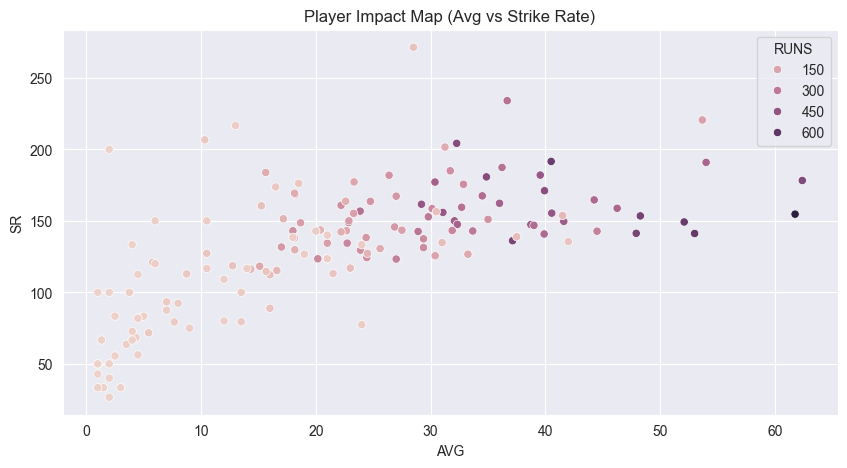

In [73]:
sns.scatterplot(data=df_2007, x="AVG", y="SR", hue="RUNS", alpha=1,color='red')
plt.title("Player Impact Map (Avg vs Strike Rate)")
plt.show()

## 1. Box Plot Analysis (Core Distribution + Outliers)

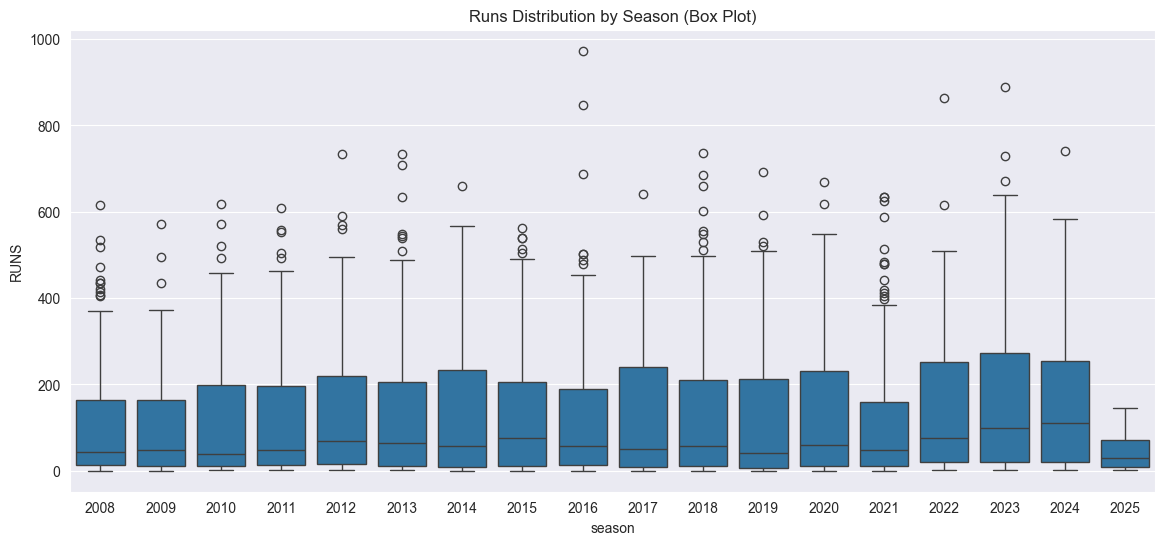

In [77]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x="season", y="RUNS")
plt.title("Runs Distribution by Season (Box Plot)")
# plt.xticks(rotation=45)
plt.show()

## Conclusion

Both the median and spread of runs per player have increased over time, indicating greater scoring opportunities and more frequent standout performances.

Key Insights
- Recent seasons show higher medians and larger interquartile ranges.
- Outliers above 900 runs demonstrate exceptional individual campaigns (e.g., Virat Kohli's 973 runs in 2016).
- Seasons 2022–2024 have the widest distributions, reflecting stronger batting performances across many players.
- 2025 has a compressed distribution because the season is still in progress.

## Strike Rate Distribution by Status (Out vs Not Out)

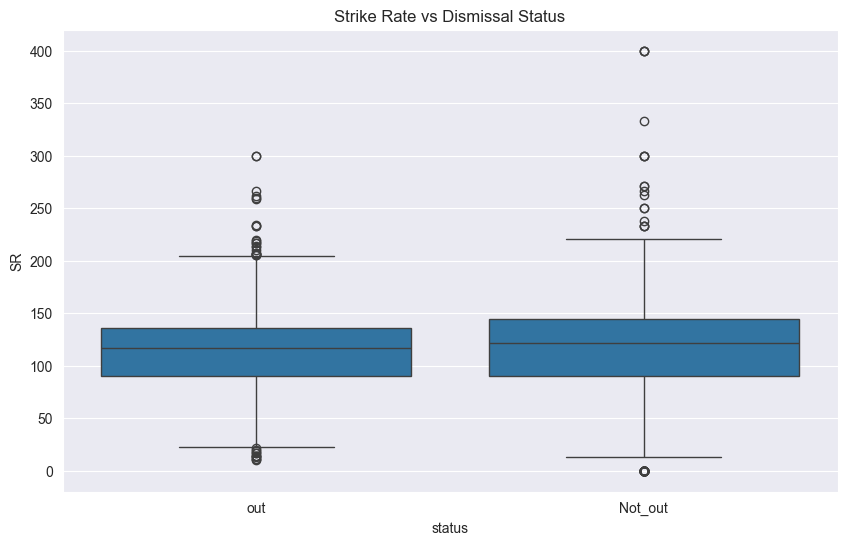

In [78]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="status", y="SR")
plt.title("Strike Rate vs Dismissal Status")
plt.show()

## Batting Average Spread (Elite Filter)

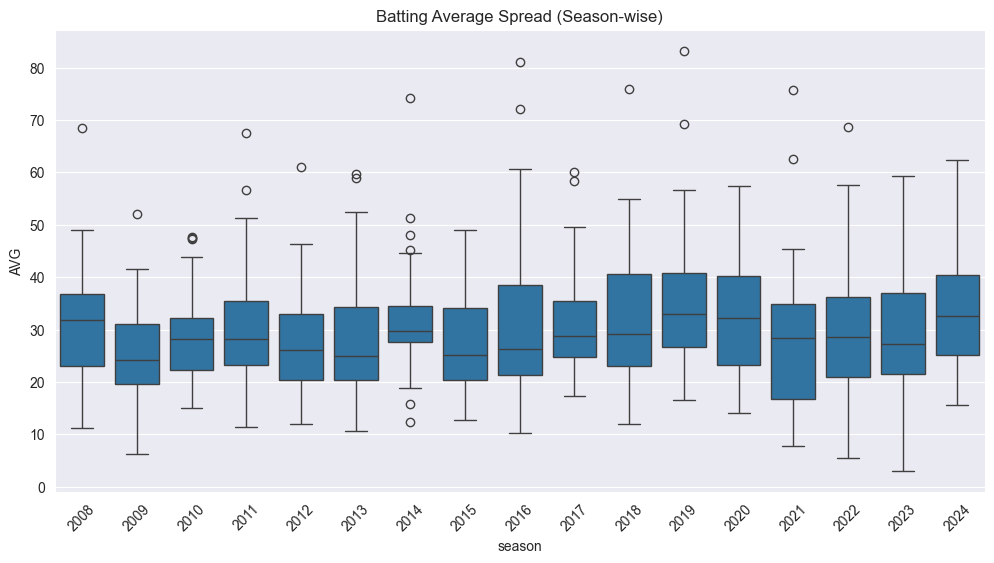

In [79]:
elite = df[df["INNS"] >= 10]

plt.figure(figsize=(12,6))
sns.boxplot(data=elite, x="season", y="AVG")
plt.title("Batting Average Spread (Season-wise)")
plt.xticks(rotation=45)
plt.show()

## 2. Swarm Plot (Player-Level Distribution)

## Runs Distribution (Top Sample Players)

Index(['Virat Kohli', 'Shikhar Dhawan', 'Rohit Sharma', 'David Warner',
       'Suresh Raina'],
      dtype='object', name='player_name')


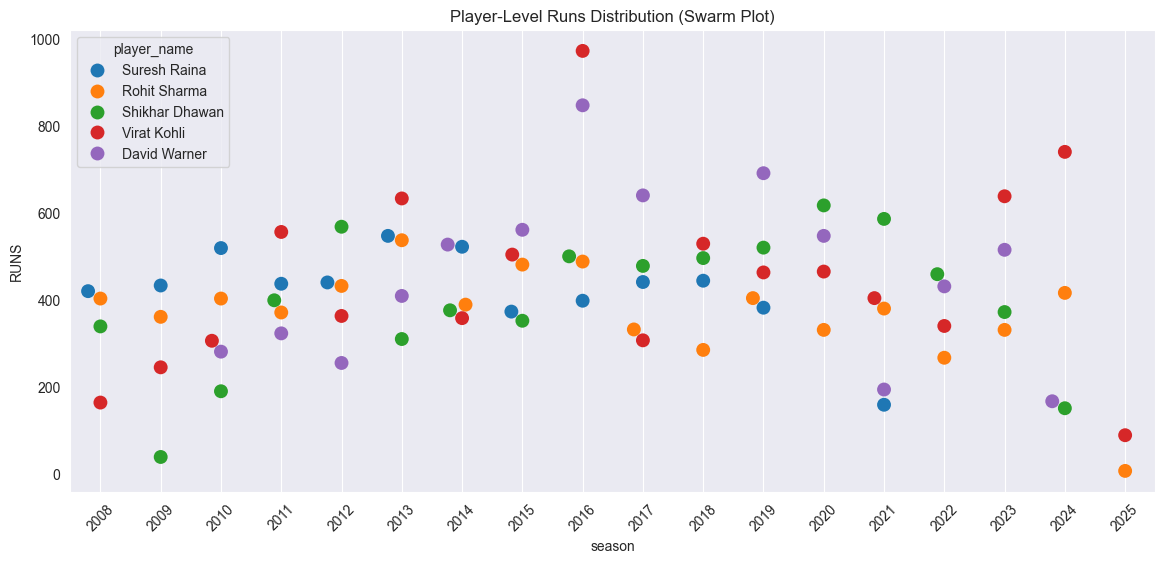

In [87]:
top_players = df.groupby("player_name")["RUNS"].sum().sort_values(ascending=False).head(5).index
sample = df[df["player_name"].isin(top_players)]

print(top_players)
plt.figure(figsize=(14,6))
sns.swarmplot(data=sample, x="season", y="RUNS", size=10,hue="player_name")
plt.title("Player-Level Runs Distribution (Swarm Plot)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [84]:
top_players

Index(['Virat Kohli', 'Shikhar Dhawan', 'Rohit Sharma', 'David Warner',
       'Suresh Raina', 'MS Dhoni', 'Chris Gayle', 'Robin Uthappa',
       'Ajinkya Rahane', 'AB de Villiers'],
      dtype='object', name='player_name')

## SR Swarm by Season

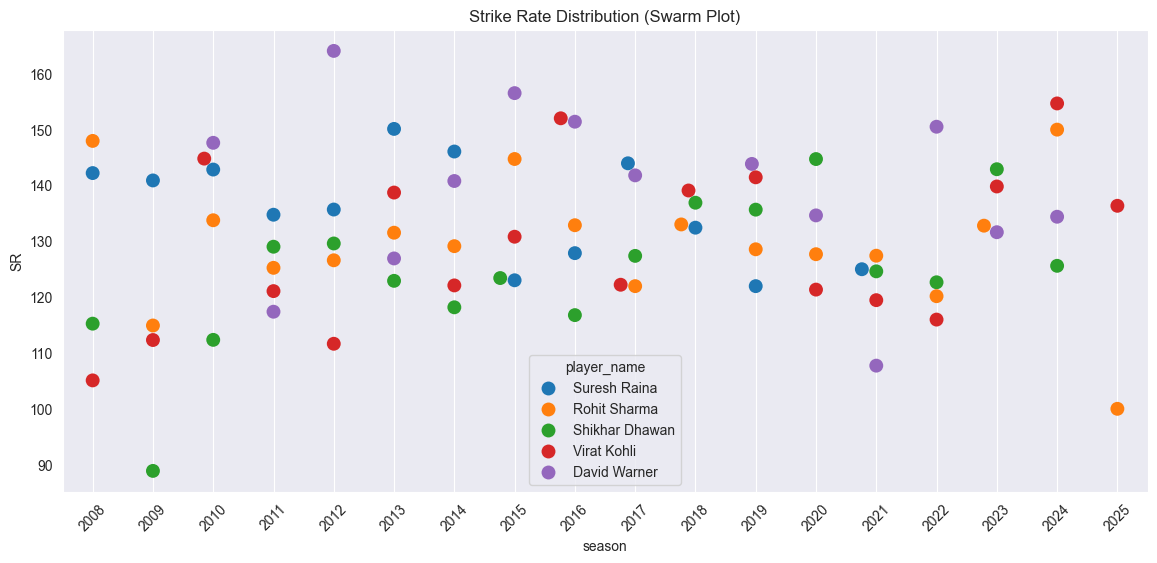

In [92]:
plt.figure(figsize=(14,6))
sns.swarmplot(data=sample, x="season", y="SR", size=10,hue="player_name")
plt.title("Strike Rate Distribution (Swarm Plot)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 7. Player-Level Runs Distribution (Swarm Plot)
Conclusion

The swarm plot illustrates how elite batters have performed across seasons, revealing both consistency and peak years.

Key Insights
- Virat Kohli exhibits the highest single-season score (~973 runs in 2016), the best in IPL history.
- David Warner stands out for remarkable consistency, frequently scoring 500+ runs.
- Rohit Sharma shows longevity, though with fewer exceptionally high peaks.
- Shikhar Dhawan maintains steady performance across many seasons.
- Suresh Raina was one of the most reliable run-scorers during the IPL's early and middle years.

##  4. Combined Advanced Charts (VERY IMPORTANT)

### Box + Swarm Overlay (Best Deep Insight Chart)

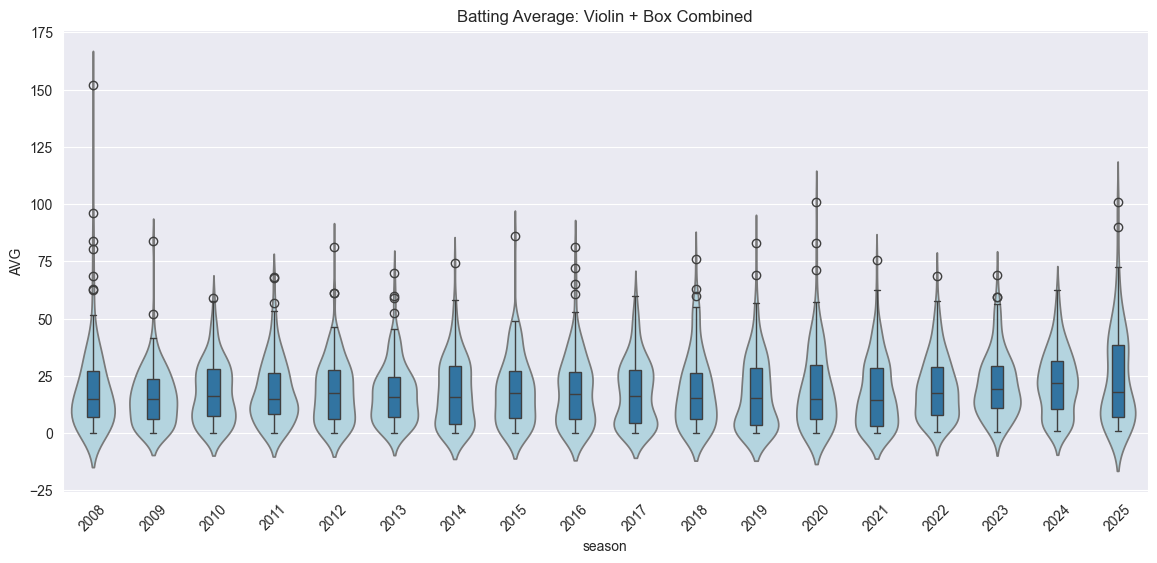

In [94]:
plt.figure(figsize=(14,6))

sns.violinplot(data=df, x="season", y="AVG", inner=None, color="lightblue")
sns.boxplot(data=df, x="season", y="AVG", width=0.2)

plt.title("Batting Average: Violin + Box Combined")
plt.xticks(rotation=45)
plt.show()

In [98]:
import os
os.getcwd()

'R:\\sipps_ss\\api_datas\\ip;l_'